In [1]:
# Set working directory
setwd(".")
getwd()

# Load package
library(e1071)
library(ctsmTMB)
library(dplyr)
library(lubridate)
library(readr)
library(ggplot2)
library(data.table)
library(ggplot2)
library(patchwork)

[1] "/Users/chrix/Projects/AdvTSA/assignment3"

Warning message:
"package 'e1071' was built under R version 4.3.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'lubridate' was built under R version 4.3.3"

Attaching package: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union



Attaching package: 'ggplot2'


The following object is masked from 'package:e1071':

    element


Warning message:
"package 'data.table' was built under R version 4.3.3"

Attaching package: 'data.table'


The following objects are masked from 'package:lubridate':

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year


The following objects are masked from 'package:dplyr':

    between, first, last




## 0. DATA LOADING AND PREPROCESSING

In [2]:
# 1. Load Data
data <- read.csv("ex2_overflow.csv", header = TRUE, sep = ",", stringsAsFactors = FALSE)

# 2. 数据清洗
# 将时间戳转换为相对时间（小时），这有助于优化器收敛
data <- data %>%
  mutate(
    time = as.POSIXct(timestamp, format = "%Y-%m-%d %H:%M:%S", tz = "UTC"),
    t = as.numeric(difftime(time, min(time), units = "hour"))
  ) %>%
  arrange(t) %>%
  select(t, rainfall, stormwater)

head(data)

,t,rainfall,stormwater
,<dbl>,<dbl>,<dbl>
1,0.00000000,0.003,0
2,0.01666667,0.000,0
3,0.03333333,0.000,0
4,0.05000000,0.000,0
5,0.06666667,0.000,0
6,0.08333333,0.000,0


## PART 2.2.1: LINEAR RESERVOIR MODEL

In [3]:
model <- ctsmTMB$new()

# Differential Equation
n = 3

model$addSystem(
  dx1 ~ A * rainfall * dt - (3/K) * x1 * dt + sigma_x * dw1,
  dx2 ~ (3/K) * x1 * dt - (3/K) * x2 * dt + sigma_x * dw2,
  dx3 ~ (3/K) * x2 * dt - (3/K) * x3 * dt + sigma_x * dw3,
  dx4 ~ (3/K) * x3 * dt + sigma_x * dw4
)

#Parameters and estimation
model$addObs(stormwater ~ x4)
model$setVariance(stormwater ~ sigma_y * sigma_y)
model$addInput(rainfall)

model$setParameter(
  A       = c(initial = 1,  lower = 1e-6, upper = 1e3),
  K       = c(initial = 10, lower = 1e-6, upper = 1e4),
  sigma_x = c(initial = 0.1, lower = 1e-8, upper = 10),
  sigma_y = c(initial = 0.1, lower = 1e-8, upper = 10)
)
model$setInitialState(list(c(0, 0, 0, 0), diag(c(0.1, 0.1, 0.1, 0.1)) ))

# now estimate
fit <- model$estimate(data)

summary(fit)
print(fit)

A       <- coef(fit)["A"]
K       <- coef(fit)["K"]
sigma_x <- coef(fit)["sigma_x"]
sigma_y <- coef(fit)["sigma_y"]

Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...



  0:     731.15582:  1.00000  10.0000 0.100000 0.100000
 10:    -1211.7308:  1.84141  4.34491 0.251015 1.00000e-08
 20:    -1269.0604:  2.46389  2.26770 0.242104 1.00000e-08
 30:    -1385.4631:  1.63586  2.27292 0.171084 1.00000e-08
 40:    -1471.9965:  1.09664  1.45070 0.159417 1.00000e-08


	 Optimization finished!:
            Elapsed time: 0.194 seconds.
            The objective value is: -1.471997e+03
            The maximum gradient component is: 4.2e-03
            The convergence message is: relative convergence (4)
            Iterations: 40
            Evaluations: Fun: 59 Grad: 41
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Finished!



Coefficent Matrix 
          Estimate Std. Error t value Pr(>|t|)    
A       1.09664060 0.05707046  19.216   <2e-16 ***
K       1.45070179 0.05825150  24.904   <2e-16 ***
sigma_x 0.15941725 0.00461006  34.580   <2e-16 ***
sigma_y 0.00000001 0.00154065   0.000        1    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1
Coefficent Matrix 
          Estimate Std. Error t value Pr(>|t|)    
A       1.09664060 0.05707046  19.216   <2e-16 ***
K       1.45070179 0.05825150  24.904   <2e-16 ***
sigma_x 0.15941725 0.00461006  34.580   <2e-16 ***
sigma_y 0.00000001 0.00154065   0.000        1    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


Plot linear model

Number of reservoirs (n): 3 
Number of states: 4 


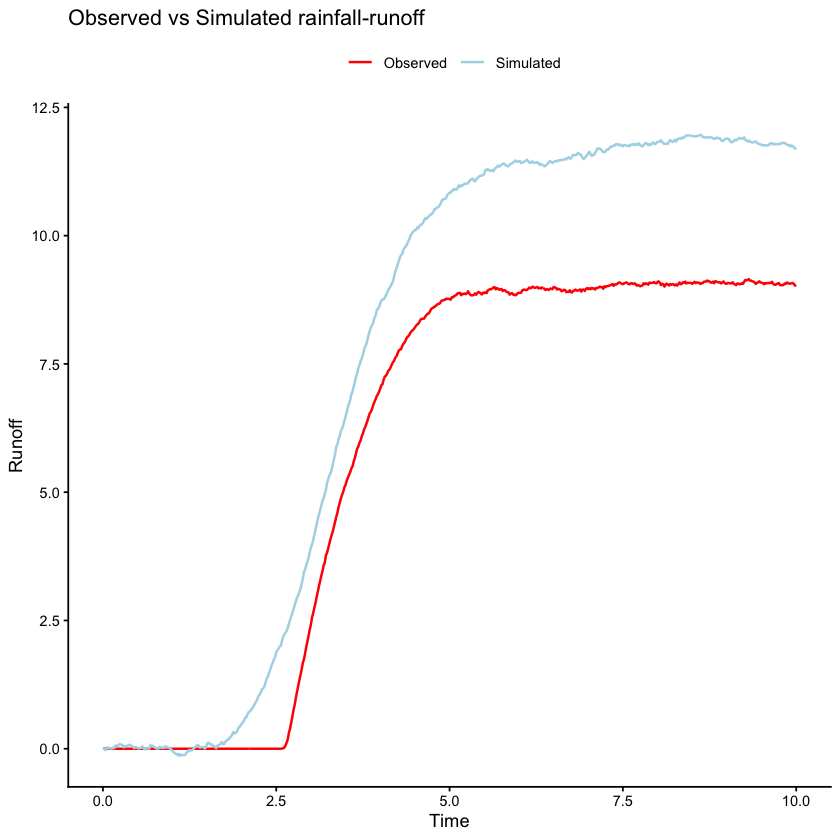

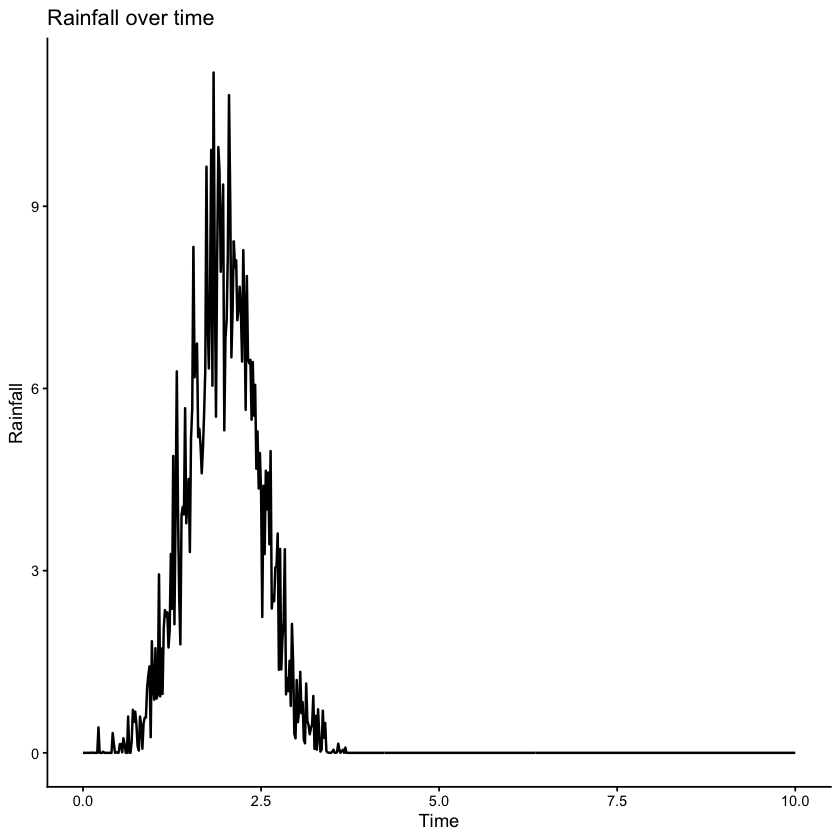

In [4]:
# ---- Choose n (same n as in your ctsmTMB model) ----
n <- 3                 # e.g. 1, 2, 3, ..., 6
n_states <- n + 1      # x1, x2, ..., x_{n+1}

cat("Number of reservoirs (n):", n, "\n")
cat("Number of states:", n_states, "\n")

# ---- Coefficients from fit (or take from coef(fit)) ----
A <- 1.0870
K <- 1.4297
sigma_x <- 0.1599
sigma_y <- 0.0000001

# Time handling 
time <- if ("t" %in% names(data)) data$t else data$time
time_num <- as.numeric(time)
n_t <- length(time_num)

rain <- data$rainfall
rain[!is.finite(rain)] <- 0

# State matrix: rows = time, cols = x1..x_{n+1} 
X <- matrix(0, nrow = n_t, ncol = n_states)
colnames(X) <- paste0("x", 1:n_states)

set.seed(123)

# Euler–Maruyama simulation matching your SDE structure 
for (i in 2:n_t) {
  dt_i <- time_num[i] - time_num[i - 1]
  stopifnot(is.finite(dt_i) && dt_i > 0)

  # Brownian increments for each state
  dw <- rnorm(n_states, mean = 0, sd = sqrt(dt_i))

  # previous state
  x_prev <- X[i - 1, ]

  # 1) First reservoir:
  
  X[i, 1] <- x_prev[1] +
    (A * rain[i] - (n / K) * x_prev[1]) * dt_i +
    sigma_x * dw[1]

  # 2) Middle reservoirs (if any)
  if (n_states > 2) {
    for (k in 2:(n_states - 1)) {
      # dx_k = (n/K)*x_{k-1} - (n/K)*x_k + noise
      X[i, k] <- x_prev[k] +
        ((n / K) * x_prev[k - 1] - (n / K) * x_prev[k]) * dt_i +
        sigma_x * dw[k]
    }
  }

  # 3) Last reservoir:
  X[i, n_states] <- x_prev[n_states] +
    ( (n / K) * x_prev[n_states - 1] ) * dt_i +
    sigma_x * dw[n_states]
}

# Runoff / stormwater = last state x_{n+1} 
stormwater_sim <- X[, n_states]


df_plot <- data.frame(
  time      = time,
  observed  = data$stormwater,
  simulated = stormwater_sim,
  rainfall  = data$rainfall
)



ggplot(df_plot, aes(x = time)) +
  geom_line(aes(y = observed,  color = "Observed"), linewidth = 0.7) +
  geom_line(aes(y = simulated, color = "Simulated"), linewidth = 0.7) +
  scale_color_manual(values = c("Observed" = "red",
                                "Simulated" = "lightblue")) +
  labs(
    title = "Observed vs Simulated rainfall-runoff",
    y = "Runoff",
    x = "Time",
    color = ""          # Legend title
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 13),
    legend.position = "top"   # move legend above plot (assignment style)
  )


## ---- Plot 2: Rainfall ----
ggplot(df_plot, aes(x = time, y = rainfall)) +
  geom_line(linewidth = 0.7, color = "black") +
  labs(
    title = "Rainfall over time",
    y = "Rainfall",
    x = "Time"
  ) +
  theme_classic() +
  theme(
    plot.title = element_text(size = 13)
  )


The linear model likely fails to capture the dynamics of the system due to its inability to account for non-linear relationships and interactions present in the data. This limitation can lead to oversimplified predictions that do not accurately reflect the underlying processes governing the system's behavior.

## PART 2.2.2: NONLINEAR OVERFLOW MODEL

In [5]:
model <- ctsmTMB$new()

n <- 3

model$addSystem(
  dx1 ~ A * rainfall * dt - (3 / K) * x1 * dt + sigma_x * dw1,
  dx2 ~ (3 / K) * x1 * dt - (3 / K) * x2 * dt + sigma_x * dw2,
  dx3 ~ (3 / K) * x2 * dt - (3 / K) * x3 * dt + sigma_x * dw3,
  dx4 ~ (3 / K) * x3 * (1 / (1 + exp(-alpha * (x3 - beta)))) * dt + sigma_x * dw4
)

model$addObs(stormwater ~ x4)
model$setVariance(stormwater ~ sigma_y^2)
model$addInput(rainfall)

model$setParameter(
  A       = c(initial = 0.9,  lower = 1e-6, upper = 10),
  K       = c(initial = 1.3,  lower = 1e-3, upper = 20),
  sigma_x = c(initial = 0.15, lower = 1e-4, upper = 5),
  sigma_y = c(initial = 0.01, lower = 1e-4, upper = 5),
  alpha   = c(initial = 5,    lower = 0.1,  upper = 10),
  beta    = c(initial = 2,    lower = 0.5,  upper = 6)
)

model$setInitialState(list(c(0, 0, 0, 0), diag(c(0.1, 0.1, 0.1, 0.1))))

fit_222 <- model$estimate(data)
summary(fit_222)

Checking model components...

Checking and setting data...

Constructing objective function and derivative tables...

Minimizing the negative log-likelihood...



  0:    -1412.7396: 0.900000  1.30000 0.150000 0.0100000  5.00000  2.00000
 10:    -1512.9156:  1.10798  1.54747 0.147897 0.000100000  4.99876  1.94737
 20:    -1524.4388:  1.24881  1.71655 0.148282 0.000244013  4.94734  2.18275
 30:    -1525.2041:  1.26180  1.74540 0.147775 0.000263531  4.93278  2.22359
 40:    -1527.5837:  1.41827  1.75727 0.144376 0.00204717  4.01479  2.38150
 50:    -1528.3029:  1.46779  1.70993 0.144803 0.00178821  2.90809  2.33278


	 Optimization finished!:
            Elapsed time: 0.272 seconds.
            The objective value is: -1.528303e+03
            The maximum gradient component is: 4.2e-04
            The convergence message is: relative convergence (4)
            Iterations: 52
            Evaluations: Fun: 78 Grad: 53
            See stats::nlminb for available tolerance/control arguments.

Returning results...

Finished!



Coefficent Matrix 
         Estimate Std. Error t value  Pr(>|t|)    
A       1.4677150  0.0912744 16.0802 < 2.2e-16 ***
K       1.7099554  0.0696187 24.5617 < 2.2e-16 ***
sigma_x 0.1447935  0.0066020 21.9317 < 2.2e-16 ***
sigma_y 0.0017928  0.0034657  0.5173 0.6051398    
alpha   2.9089411  0.7756498  3.7503 0.0001939 ***
beta    2.3327380  0.2082525 11.2015 < 2.2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1


[1] "---- Parameters from the non-linear fit (2.2.2) ----"
[1] 1.467714996 1.709955426 0.144793490 0.001792794 2.908941058 2.332737995


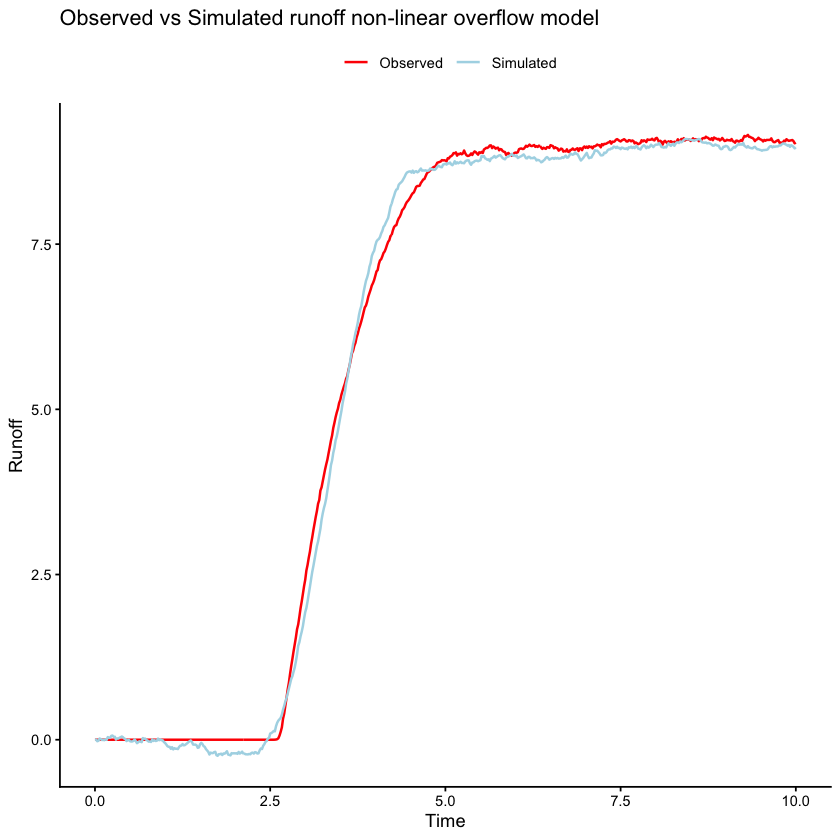

In [6]:
library(ggplot2)

print("---- Parameters from the non-linear fit (2.2.2) ----")
par_hat <- model$getParameters(type = "all", value = "estimate")
print(par_hat)

A       <- 1.433
K       <- 1.670
sigma_x <- 0.147
sigma_y <- 0.001
alpha   <- 2.855
beta    <- 2.209

# ---- Time and input ----
time     <- data$t
time_num <- as.numeric(time)
n_t      <- length(time_num)

rain <- data$rainfall
rain[!is.finite(rain)] <- 0

n        <- 3
n_states <- n + 1

X <- matrix(0, nrow = n_t, ncol = n_states)
colnames(X) <- paste0("x", 1:n_states)

set.seed(123)

for (i in 2:n_t) {
  dt_i <- time_num[i] - time_num[i - 1]
  stopifnot(is.finite(dt_i) && dt_i > 0)

  dw     <- rnorm(n_states, 0, sqrt(dt_i))
  x_prev <- X[i - 1, ]

  # linear part:
  X[i, 1] <- x_prev[1] +
    (A * rain[i] - (n / K) * x_prev[1]) * dt_i + sigma_x * dw[1]

  X[i, 2] <- x_prev[2] +
    ((n / K) * x_prev[1] - (n / K) * x_prev[2]) * dt_i + sigma_x * dw[2]

  X[i, 3] <- x_prev[3] +
    ((n / K) * x_prev[2] - (n / K) * x_prev[3]) * dt_i + sigma_x * dw[3]

  # non-linear overflow into x4:
  q <- 1 / (1 + exp(-alpha * (x_prev[3] - beta)))
  X[i, 4] <- x_prev[4] +
    ((n / K) * x_prev[3] * q) * dt_i + sigma_x * dw[4]
}

stormwater_sim <- X[, 4]

df_plot <- data.frame(
  time      = time,
  observed  = data$stormwater,
  simulated = stormwater_sim,
  rainfall  = data$rainfall
)

# ---- Plot 1: Observed vs simulated (2.2.2) ----
ggplot(df_plot, aes(x = time)) +
  geom_line(aes(y = observed,  color = "Observed"), linewidth = 0.7) +
  geom_line(aes(y = simulated, color = "Simulated"), linewidth = 0.7) +
  scale_color_manual(values = c("Observed" = "red",
                                "Simulated" = "lightblue")) +
  labs(
    title = "Observed vs Simulated runoff non-linear overflow model",
    y = "Runoff",
    x = "Time",
    color = ""
  ) +
  theme_classic() +
  theme(
    legend.position = "top",
    plot.title = element_text(size = 13)
  )



## PART 2.2.3: CORRELATION MATRIX


In [7]:
f <- fit_222

cov_mat <- f$cov.fixed

cor_mat <- cov2cor(cov_mat)

round(cor_mat, 3)

,A,K,sigma_x,sigma_y,alpha,beta
A,1.000,-0.111,0.007,-0.004,-0.683,0.614
K,-0.111,1.000,-0.001,-0.002,0.413,0.422
sigma_x,0.007,-0.001,1.000,-0.764,-0.011,0.003
sigma_y,-0.004,-0.002,-0.764,1.000,0.006,-0.003
alpha,-0.683,0.413,-0.011,0.006,1.000,-0.233
beta,0.614,0.422,0.003,-0.003,-0.233,1.000


Interpretation:

- There is a strong negative correlation (-0.764) between the system noise (σx​) and the observation noise (σy​). This indicates an identification issue where the model struggles to distinguish between process noise (randomness in the water accumulation) and measurement noise. The optimizer can trade off increasing one sigma by decreasing the other without significantly affecting the likelihood. This is common when data is limited or the system dynamics are smooth.
- $A$ vs $\alpha$ (-0.683): There is a moderate to strong negative correlation. A larger catchment area (A, meaning more water enters) can be compensated for by a "softer" or more gradual overflow switch (smaller $\alpha$).  
- $A$ vs $\beta$ (0.614): There is a moderate positive correlation. If the catchment area A increases (more inflow), the threshold $\beta$ must also increase to prevent the overflow from starting too early. This makes physical sense: more water in means the "bucket" fills faster, so to match the observed timing of overflow, the bucket effectively needs to be "taller" (higher $\beta$).  
- The correlation between A and K is quite low (-0.111). It means the model can independently estimate how much water enters (A) and how fast it flows through the linear reservoirs (K). They are well-identified separate physical properties.

## PART 2.2.4: VISUALIZATION & VALIDATION

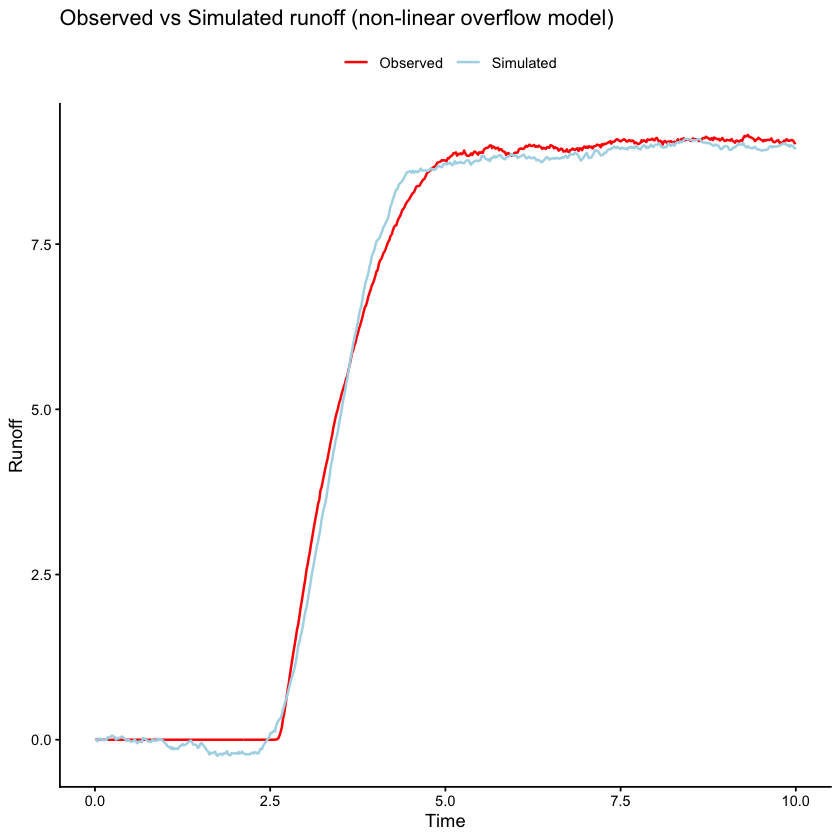

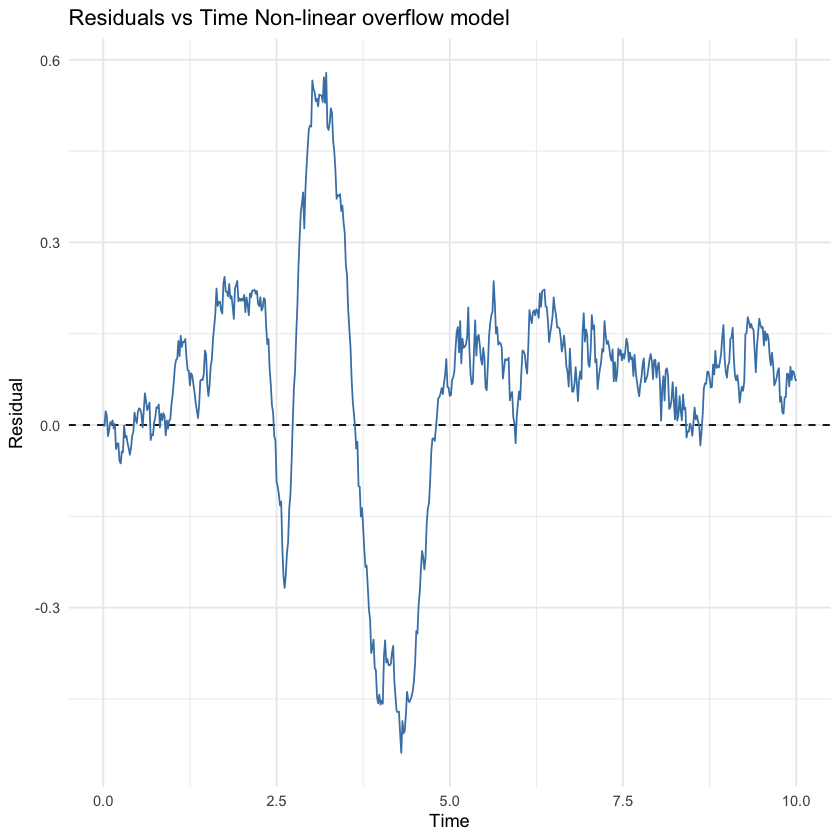

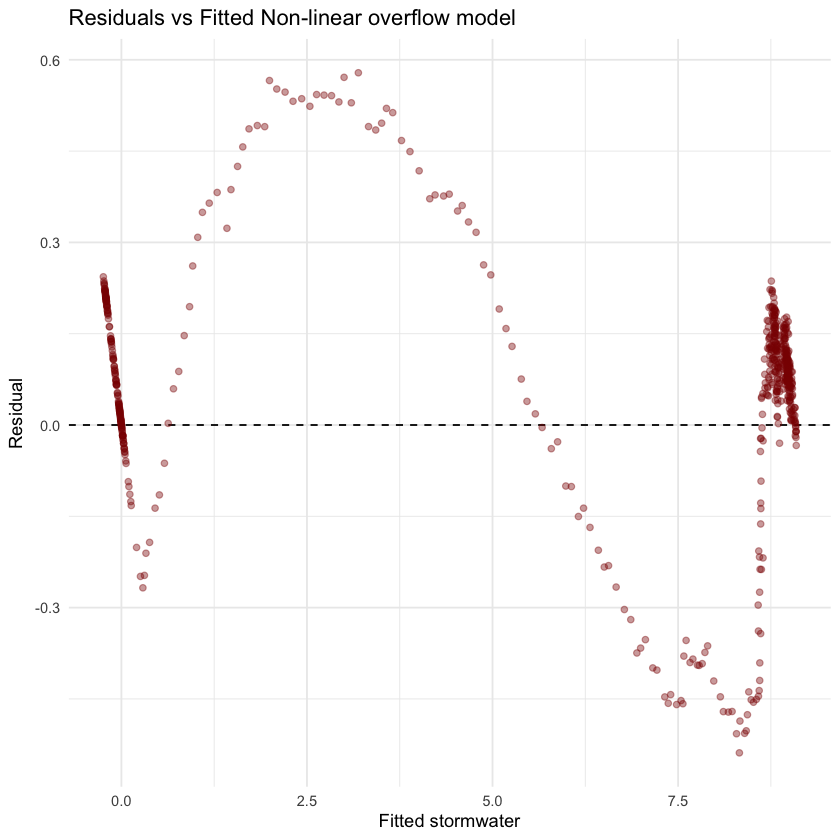

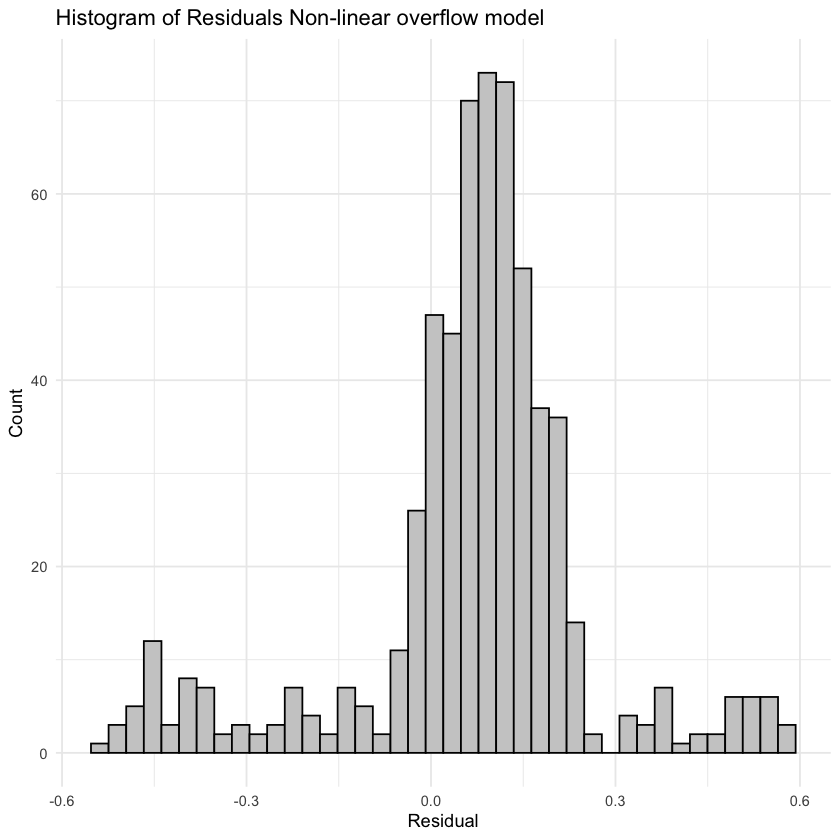

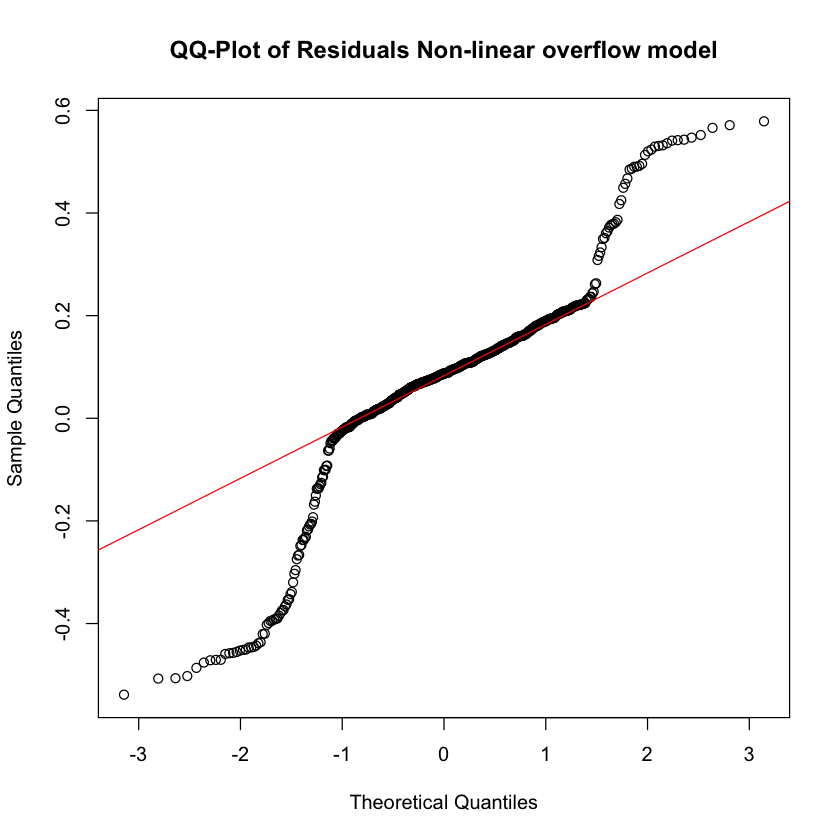

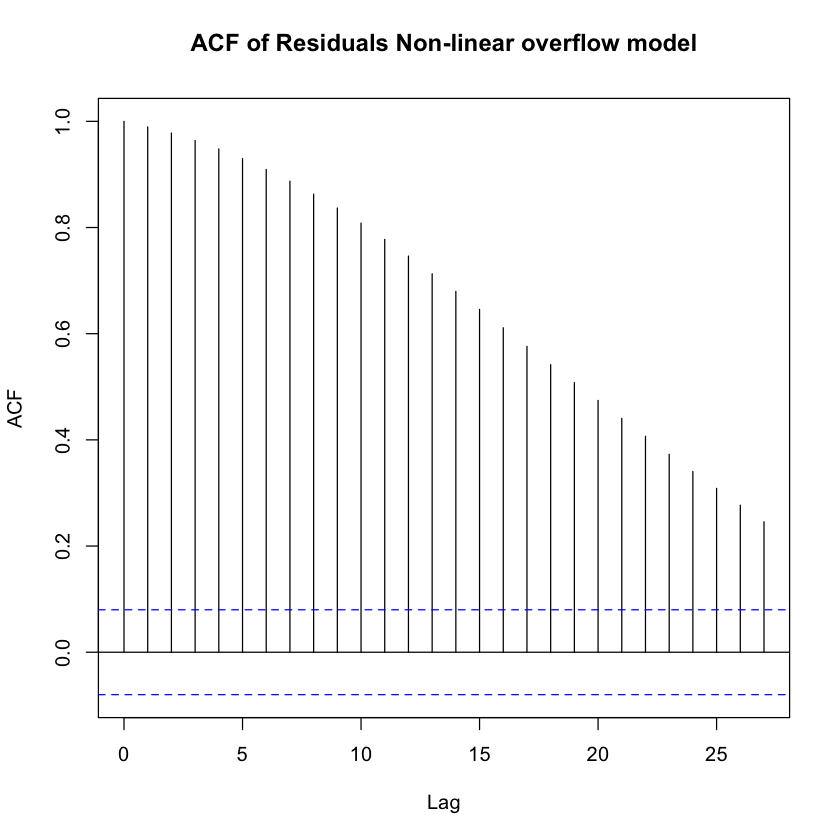

In [8]:

ggplot(df_plot, aes(x = time)) +
  geom_line(aes(y = observed,  color = "Observed"), linewidth = 0.7) +
  geom_line(aes(y = simulated, color = "Simulated"), linewidth = 0.7) +
  scale_color_manual(values = c("Observed" = "red",
                                "Simulated" = "lightblue")) +
  labs(
    title = "Observed vs Simulated runoff (non-linear overflow model)",
    y = "Runoff",
    x = "Time",
    color = ""
  ) +
  theme_classic() +
  theme(
    legend.position = "top",
    plot.title = element_text(size = 13)
  )

# ============================================================
# =============== Residual Analysis for 2.2.2 =================
# ============================================================

# 1) Compute residuals
df_plot$residual <- df_plot$observed - df_plot$simulated

# 2) Residuals vs Time
ggplot(df_plot, aes(x = time, y = residual)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_line(color = "steelblue") +
  labs(
    title = "Residuals vs Time Non-linear overflow model",
    x = "Time", y = "Residual"
  ) +
  theme_minimal()

# 3) Residuals vs Fitted
ggplot(df_plot, aes(x = simulated, y = residual)) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  geom_point(alpha = 0.4, color = "darkred") +
  labs(
    title = "Residuals vs Fitted Non-linear overflow model",
    x = "Fitted stormwater", y = "Residual"
  ) +
  theme_minimal()

# 4) Histogram of residuals
ggplot(df_plot, aes(x = residual)) +
  geom_histogram(bins = 40, colour = "black", fill = "grey80") +
  labs(
    title = "Histogram of Residuals Non-linear overflow model",
    x = "Residual", y = "Count"
  ) +
  theme_minimal()

# 5) QQ-Plot
qqnorm(df_plot$residual,
       main = "QQ-Plot of Residuals Non-linear overflow model")
qqline(df_plot$residual, col = "red")

# 6) Autocorrelation function (ACF)
acf(df_plot$residual,
    main = "ACF of Residuals Non-linear overflow model")


- Visual Fit: The plot "Observed vs Simulated runoff" shows a good visual fit. The simulated runoff (light blue line) closely tracks the observed runoff (red line) throughout the entire event.
- Dynamics: The model successfully captures the initial delay (dead zone) before runoff begins (around t=2.5 hours), the steep rise during the rainfall event, and the plateau phase after the rain stops. This confirms that the non-linear sigmoid function correctly models the overflow mechanism.
- Residuals vs. Time: The residuals fluctuate around zero but show a distinct pattern. There is a large positive spike followed by a dip around the time of the rapid rise in runoff (t≈2.5−4 hours). This indicates the model doesn't perfectly capture the exact timing or sharpness of the overflow onset, which is expected given the smooth nature of the sigmoid function versus a potentially sharper physical threshold. Later residuals (t>5) are smaller but still show some autocorrelation. 
- Residuals vs. Fitted: There is a clear pattern here as well, particularly at lower flow values (onset of overflow) and at the peak flow. This heteroscedasticity suggests that the variance is not constant or that the structural model (the specific shape of the non-linearity) could be further refined.
- ACF (Autocorrelation): The ACF plot shows significant positive autocorrelation at initial lags that decays slowly. This is typical for dynamic system models where the state at time t depends heavily on t−1. It implies the "white noise" assumption for the residuals is not fully met; there is structure in the error that the model hasn't explained (likely due to the simplified representation of the overflow physics). 
- QQ-Plot & Histogram: The residuals are roughly normally distributed in the center but have heavy tails (deviations from the red line in the QQ-plot at both ends). This confirms that extreme errors (both over- and under-estimation during the rapid change phase) are more frequent than a normal distribution would predict.


Conclusion:  Yes, we are satisfied. While the residual analysis reveals some statistical imperfections (autocorrelation and non-constant variance).